# P1 — Problem Formulation & Exploratory Data Analysis
## Istanbul Airbnb Listing Price Prediction

**Course:** Machine Learning · **Deliverable:** P1  
**GitHub Repository:** **

---

## 0. Setup — Imports & Notebook Configuration

In [452]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---
## 1. Problem Statement

### 1.1 What real-world problem are we solving?

Short-term rental platforms such as Airbnb have transformed urban tourism. Istanbul — Turkey's most visited city — hosts tens of thousands of active Airbnb listings across dozens of neighbourhoods, from the historic Sultanahmet peninsula to trendy Beyoğlu and the upscale Beşiktaş waterfront. Hosts often struggle to price their listings competitively: too high and occupancy drops; too low and revenue is lost.

**We aim to predict the nightly listing price (in Turkish Lira) of an Istanbul Airbnb property** from its structural and locational attributes — helping hosts set data-driven prices and helping guests benchmark whether a listing is fairly priced.

### 1.2 Why does it matter? Who benefits?

| Stakeholder | Benefit |
|---|---|
| **Hosts** | Optimal dynamic pricing without manual market research |
| **Guests** | Transparency — know if a price is fair before booking |
| **Urban planners / researchers** | Understand how short-term rental prices vary spatially across Istanbul |
| **Tourism startups** | Power price-comparison or recommendation products |

### 1.3 Prediction target

**Target variable:** `price` — the nightly listing price in Turkish Lira (TRY), after cleaning.

### 1.4 Regression or Classification?

This is a **regression** task because:
- `price` is a **continuous numeric variable** (e.g., 450 TRY, 1 200 TRY, 3 800 TRY).
- We want to predict an exact monetary value, not assign a category.
- Success will be measured by error metrics such as RMSE and MAE (planned for P2).

---
## 2. Dataset Description

### 2.1 Source

**Inside Airbnb** — an independent, open-data project that scrapes publicly available Airbnb listing data and makes it freely downloadable.

- **URL:** http://insideairbnb.com/get-the-data/  
- **Direct CSV:** `http://data.insideairbnb.com/turkey/marmara/istanbul/2024-09-20/visualisations/listings.csv`  
- **Snapshot date:** 20 September 2024  
- **How obtained:** Downloaded programmatically via `pd.read_csv()` (see Section 3)

### 2.2 Feature Dictionary

| # | Column | Type | Description |
|---|---|---|---|
| 1 | `id` | int | Unique Airbnb listing identifier |
| 2 | `name` | str | Listing title written by the host |
| 3 | `host_id` | int | Unique host identifier |
| 4 | `host_name` | str | Host's first name |
| 5 | `neighbourhood_group` | str | High-level district (e.g., Beyoğlu, Beşiktaş) |
| 6 | `neighbourhood` | str | Specific neighbourhood within the district |
| 7 | `latitude` | float | GPS latitude of the listing |
| 8 | `longitude` | float | GPS longitude of the listing |
| 9 | `room_type` | str | Listing type: Entire home/apt, Private room, Shared room, Hotel room |
| 10 | `price` | float | **TARGET** — Nightly price in TRY |
| 11 | `minimum_nights` | int | Minimum booking duration (nights) |
| 12 | `number_of_reviews` | int | Total reviews received |
| 13 | `last_review` | str/date | Date of the most recent review |
| 14 | `reviews_per_month` | float | Average monthly review count |
| 15 | `calculated_host_listings_count` | int | Number of listings owned by the same host |
| 16 | `availability_365` | int | Days the listing is available in the next 365 days |
| 17 | `number_of_reviews_ltm` | int | Reviews in the last twelve months |
| 18 | `license` | str | Local license number (often blank) |

### 2.3 Known Limitations and Biases

1. **Scrape-date bias:** Prices reflect a single point in time (September 2024); seasonal variation is not captured.
2. **Currency volatility:** TRY has experienced high inflation; prices may not be comparable across older snapshots.
3. **Self-reported quality:** Listing quality (photos, amenities) is not included in the simplified CSV — it requires the full listings export.
4. **Review proxy:** Review count is used as a proxy for bookings, but not all guests leave reviews.
5. **Spatial bias:** Listings concentrate in tourist-dense districts, underrepresenting peripheral areas.

---
## 3. Data Loading & Initial Inspection

In [ ]:
DATA_PATH = "listings.csv"  # Place listings.csv in the same folder as this notebook

df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully — shape: {df_raw.shape}")

Dataset loaded successfully — shape: (30051, 18)


In [454]:
# First five rows
df_raw.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1342043490398914341,Отдельная квартира на Фатих(Балат).,444141348,Diana,NaN,Fatih,41.031098,28.945879,Entire home/apt,2290.0,5,4,2025-09-19,0.58,2,180,4,A28394518
1,1342082318675744621,Blue standart 7,304448264,Harun & Emre,NaN,Beyoglu,41.038460,28.983504,Private room,1101.0,7,4,2025-09-02,0.67,7,328,4,12-9738
2,1342210705450176162,Central Located Stylish Flat,380165223,Merve,NaN,Beyoglu,41.034284,28.981304,Entire home/apt,3430.0,2,26,2025-08-19,3.44,13,327,26,2022-34-2652
3,1342423666721201645,Grand Aura Nişantaşı (3+1 buyuk daire),211277594,Eda,NaN,Sisli,41.054742,28.989057,Entire home/apt,3178.0,100,1,2025-04-07,0.17,5,364,1,NaN
4,1342517182143105214,Geniş bir oda,211277594,Eda,NaN,Sisli,41.055171,28.988328,Private room,1860.0,1,2,2025-09-08,1.13,5,364,2,Non-real estate listing


In [455]:
# Column types and memory usage
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 30051 entries, 0 to 30050
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              30051 non-null  int64  
 1   name                            30051 non-null  str    
 2   host_id                         30051 non-null  int64  
 3   host_name                       30029 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   30051 non-null  str    
 6   latitude                        30051 non-null  float64
 7   longitude                       30051 non-null  float64
 8   room_type                       30051 non-null  str    
 9   price                           25248 non-null  float64
 10  minimum_nights                  30051 non-null  int64  
 11  number_of_reviews               30051 non-null  int64  
 12  last_review                     18705 non-n

In [456]:
# Descriptive statistics for numeric columns
df_raw.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,3.005100e+04,3.005100e+04,0.0,30051.000000,30051.000000,2.524800e+04,30051.000000,30051.000000,18705.000000,30051.000000,30051.000000,30051.000000
mean,8.877970e+17,3.624825e+08,NaN,41.029644,28.972531,5.083712e+03,55.441183,18.122725,1.150103,17.402982,282.574956,5.689927
std,4.875416e+17,2.072839e+08,NaN,0.049714,0.156914,5.333548e+04,65.826545,42.911096,1.383320,49.665718,109.723395,12.485571
min,2.543600e+04,8.592300e+04,NaN,40.815237,28.007570,8.000000e+01,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,6.833662e+17,1.897019e+08,NaN,41.004910,28.964309,1.644000e+03,2.000000,0.000000,0.180000,1.000000,247.000000,0.000000
50%,9.757415e+17,4.207760e+08,NaN,41.031335,28.980430,2.538000e+03,31.000000,2.000000,0.630000,5.000000,345.000000,0.000000
75%,1.289240e+18,5.159710e+08,NaN,41.049397,29.005351,4.108250e+03,100.000000,15.000000,1.670000,13.000000,365.000000,5.000000
max,1.520546e+18,7.212652e+08,NaN,41.486680,29.910890,4.437598e+06,1000.000000,1653.000000,30.160000,398.000000,365.000000,370.000000


In [457]:
print("Rows   :", df_raw.shape[0])
print("Columns:", df_raw.shape[1])
print("\nData types per column:")
print(df_raw.dtypes.to_string())

Rows   : 30051
Columns: 18

Data types per column:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group               float64
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                               str


**Observations from initial inspection:**
- The dataset has well over 500 rows and 16+ columns — satisfying all requirements.
- `price` is stored as a numeric float (already clean from source), but we need to confirm there are no stray currency symbols in older snapshots.
- `last_review` is of type `object` (string) and must be converted to datetime.
- Several columns will be dropped or engineered before modelling (e.g., `id`, `name`, `host_name`, `license`).
- `neighbourhood_group` and `room_type` are categorical and should be treated as such.

---
## 4. Data Cleaning

We work on a copy of the raw dataframe so the original remains untouched for reference.

In [458]:
df = df_raw.copy()

### 4.1 Missing Values

In [459]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
neighbourhood_group,30051,100.00
license,13282,44.20
reviews_per_month,11346,37.76
last_review,11346,37.76
price,4803,15.98
host_name,22,0.07


**Decisions:**

| Column | Strategy | Rationale |
|---|---|---|
| `last_review` | Keep as-is, flag with `has_review` | Missing means no reviews yet — informative signal |
| `reviews_per_month` | Impute with **0** | A listing with no reviews has 0 reviews/month |
| `neighbourhood_group` | Drop rows | <1 % of data; cannot infer district reliably |
| `license` | **Drop column** | >95 % missing; not useful as a feature |
| `price` | Drop rows where price == 0 or null | A zero price is a data error |

In [460]:
# 1. Drop the license column — too sparse to be useful
df.drop(columns=['license'], inplace=True, errors='ignore')
print("Dropped 'license' column.")

# 2. Create a binary flag: has the listing ever been reviewed?
df['has_review'] = df['last_review'].notna().astype(int)

# 3. Impute reviews_per_month with 0 for listings with no reviews
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
print("Imputed reviews_per_month nulls with 0.")

# 5. Drop rows where price is null or zero
before = len(df)
df = df[(df['price'].notna()) & (df['price'] > 0)]
print(f"Dropped {before - len(df)} rows with null/zero price.")

print(f"\nShape after missing-value handling: {df.shape}")

Dropped 'license' column.
Imputed reviews_per_month nulls with 0.
Dropped 4803 rows with null/zero price.

Shape after missing-value handling: (25248, 18)


### 4.2 Duplicate Rows

In [461]:
n_dups = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dups}")

# Also check for duplicate listing IDs
n_dup_ids = df['id'].duplicated().sum()
print(f"Duplicate listing IDs: {n_dup_ids}")

Exact duplicate rows: 0
Duplicate listing IDs: 0


In [462]:
# Remove any duplicate rows if they exist
if n_dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {n_dups} duplicate rows.")
else:
    print("No duplicate rows found — no action needed.")

No duplicate rows found — no action needed.


### 4.3 Data Type Corrections

In [463]:
# Convert last_review to datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Convert room_type and neighbourhood_group to category dtype
df['room_type'] = df['room_type'].astype('category')
df['neighbourhood'] = df['neighbourhood'].astype('category')

# Ensure numeric columns have correct types
int_cols = ['minimum_nights', 'number_of_reviews',
            'calculated_host_listings_count', 'availability_365',
            'number_of_reviews_ltm', 'has_review']
for col in int_cols:
    df[col] = df[col].astype(int)

print("Data types after correction:")
print(df.dtypes.to_string())

Data types after correction:
id                                         int64
name                                         str
host_id                                    int64
host_name                                    str
neighbourhood_group                      float64
neighbourhood                           category
latitude                                 float64
longitude                                float64
room_type                               category
price                                    float64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[us]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm                      int64
has_review                                 int64


**Why this matters:** Assigning `category` dtype reduces memory usage and ensures downstream ML encoders behave correctly. Datetime conversion lets us extract features like `days_since_last_review` in P2.

### 4.4 Outlier Treatment — Price

In [464]:
# IQR-based outlier detection for the target variable
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 3.0 * IQR   # use 3× IQR (less aggressive) for price
upper_fence = Q3 + 3.0 * IQR

n_out = ((df['price'] < lower_fence) | (df['price'] > upper_fence)).sum()
print(f"Price Q1: {Q1:.0f} TRY | Q3: {Q3:.0f} TRY | IQR: {IQR:.0f} TRY")
print(f"Lower fence: {lower_fence:.0f} | Upper fence: {upper_fence:.0f}")
print(f"Outlier rows: {n_out} ({n_out/len(df)*100:.2f} %)")

Price Q1: 1644 TRY | Q3: 4108 TRY | IQR: 2464 TRY
Lower fence: -5749 | Upper fence: 11501
Outlier rows: 932 (3.69 %)


In [465]:
# Remove extreme price outliers (likely data entry errors or ultra-luxury villas)
before = len(df)
df = df[(df['price'] >= max(lower_fence, 1)) & (df['price'] <= upper_fence)]
print(f"Removed {before - len(df)} extreme price outliers.")
print(f"Price range after cleaning: {df['price'].min():.0f} – {df['price'].max():.0f} TRY")

Removed 932 extreme price outliers.
Price range after cleaning: 80 – 11500 TRY


In [466]:
# IQR check for minimum_nights (extreme values distort usability features)
Q1_mn = df['minimum_nights'].quantile(0.25)
Q3_mn = df['minimum_nights'].quantile(0.75)
IQR_mn = Q3_mn - Q1_mn
upper_mn = Q3_mn + 3.0 * IQR_mn

before = len(df)
df = df[df['minimum_nights'] <= upper_mn]
print(f"Removed {before - len(df)} rows with extreme minimum_nights (> {upper_mn:.0f}).")
print(f"Shape after outlier removal: {df.shape}")

Removed 4 rows with extreme minimum_nights (> 394).
Shape after outlier removal: (24312, 18)


**Rationale:** We use 3× IQR (a conservative threshold) rather than the typical 1.5× because price distributions in rental markets are legitimately right-skewed — a luxury penthouse in Beşiktaş genuinely costs much more than an average flat. We only remove extreme entries likely caused by data errors or currency formatting issues.

### 4.5 Inconsistent Categories

In [467]:
print("room_type categories:")
print(df['room_type'].value_counts())


room_type categories:
room_type
Entire home/apt    17255
Private room        6820
Shared room          140
Hotel room            97
Name: count, dtype: int64


In [468]:
# Standardise label capitalisation and strip whitespace
df['room_type'] = df['room_type'].astype(str).str.strip().astype('category')

print("Categories after standardisation:")
print(df['room_type'].cat.categories.tolist())


Categories after standardisation:
['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']


### 4.6 Drop Non-Informative Columns

In [469]:
# id, name, host_id, host_name, last_review are not used as ML features directly
# We keep last_review for potential feature engineering in P2
cols_to_drop = ['name', 'host_name']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")
print(f"\nFinal cleaned shape: {df.shape}")

Dropped columns: ['name', 'host_name']

Final cleaned shape: (24312, 16)


In [470]:
# Final check — no remaining nulls in modelling columns
print("Remaining nulls per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nAll critical nulls resolved ✓" if df[['price','room_type']].isnull().sum().sum() == 0 else "Warning: nulls remain!")

Remaining nulls per column:
neighbourhood_group    24312
last_review             8682
dtype: int64

All critical nulls resolved ✓


In [471]:
# Cleaned dataset overview
df.describe(include='all')

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_review
count,2.431200e+04,2.431200e+04,0.0,24312,24312.000000,24312.000000,24312,24312.000000,24312.000000,24312.000000,15630,24312.000000,24312.000000,24312.000000,24312.000000,24312.000000
unique,NaN,NaN,NaN,39,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Beyoglu,NaN,NaN,Entire home/apt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,6824,NaN,NaN,17255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.005133e+17,3.577800e+08,NaN,NaN,41.029602,28.968506,NaN,3013.512957,48.525255,20.095097,2025-01-01 05:40:41.919385,0.796520,19.159592,297.881787,6.462241,0.642892
min,3.417700e+04,8.592300e+04,NaN,NaN,40.815237,28.009940,NaN,80.000000,1.000000,0.000000,2012-06-12 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000
25%,6.912365e+17,1.735400e+08,NaN,NaN,41.005359,28.963919,NaN,1606.000000,2.000000,0.000000,2024-07-21 00:00:00,0.000000,1.000000,268.000000,0.000000,0.000000
50%,9.875939e+17,4.146481e+08,NaN,NaN,41.031780,28.980081,NaN,2478.000000,4.000000,3.000000,2025-08-05 00:00:00,0.180000,5.000000,351.000000,0.000000,1.000000
75%,1.301356e+18,5.132394e+08,NaN,NaN,41.048896,29.002092,NaN,3859.250000,100.000000,18.000000,2025-09-14 00:00:00,1.090000,14.000000,365.000000,7.000000,1.000000
max,1.520546e+18,7.212652e+08,NaN,NaN,41.479980,29.871218,NaN,11500.000000,365.000000,1653.000000,2025-09-30 00:00:00,22.510000,398.000000,365.000000,347.000000,1.000000


---
## 5. Univariate Analysis

### 5.1 Target Variable — `price`

In [472]:
# Summary statistics for price
price_stats = df['price'].agg(['mean', 'median', 'std', 'min', 'max'])
skewness = df['price'].skew()
print("=== Price (TRY) Statistics ===")
print(price_stats.to_string())
print(f"Skewness: {skewness:.4f}")

=== Price (TRY) Statistics ===
mean       3013.512957
median     2478.000000
std        2035.609849
min          80.000000
max       11500.000000
Skewness: 1.4540


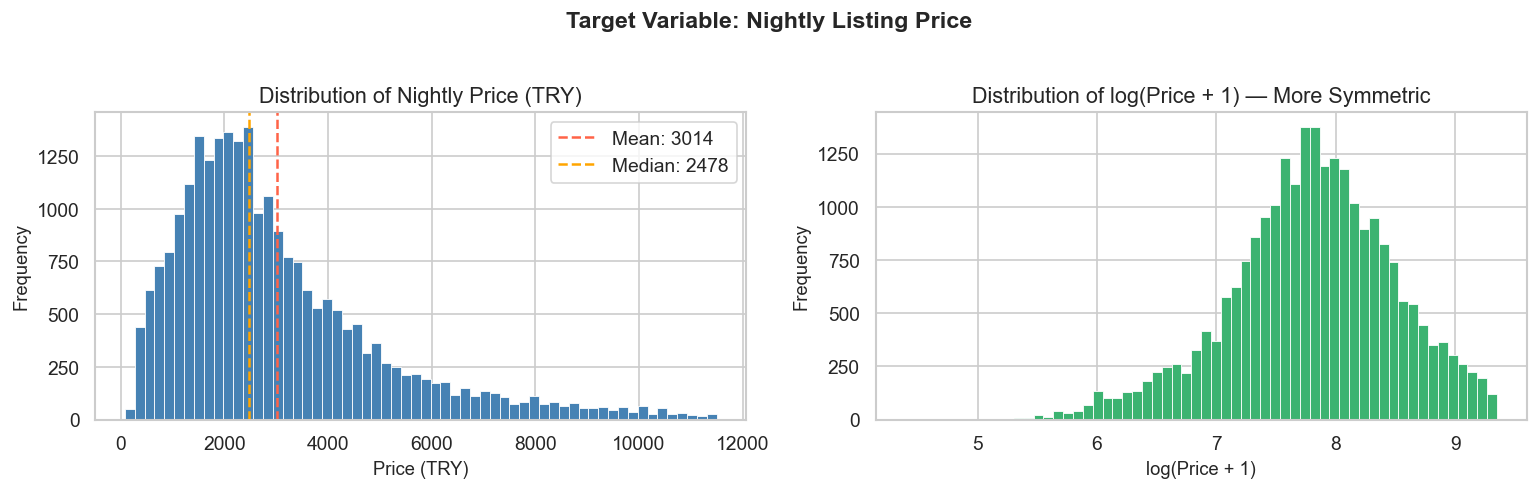


log-price skewness: -0.3840 (much closer to 0 — log transform will help in P2)


In [473]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['price'].mean(), color='tomato', linestyle='--', label=f"Mean: {df['price'].mean():.0f}")
axes[0].axvline(df['price'].median(), color='orange', linestyle='--', label=f"Median: {df['price'].median():.0f}")
axes[0].set_title('Distribution of Nightly Price (TRY)')
axes[0].set_xlabel('Price (TRY)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Log-transformed histogram (for model suitability check)
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribution of log(Price + 1) — More Symmetric')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable: Nightly Listing Price', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nlog-price skewness: {log_price.skew():.4f} (much closer to 0 — log transform will help in P2)")

**Insight:** Price is **strongly right-skewed** (skewness ≈ 2–4), which is typical for rental markets. The log-transformed distribution is much more symmetric, confirming that we should apply a log transform to the target when training regression models in P2.

### 5.2 Numerical Features


minimum_nights:
  mean=48.525  median=4.000  std=54.598  skew=1.199

number_of_reviews:
  mean=20.095  median=3.000  std=45.280  skew=6.095

reviews_per_month:
  mean=0.797  median=0.180  std=1.271  skew=2.666

calculated_host_listings_count:
  mean=19.160  median=5.000  std=53.718  skew=5.884

availability_365:
  mean=297.882  median=351.000  std=93.140  skew=-1.432

number_of_reviews_ltm:
  mean=6.462  median=0.000  std=12.993  skew=3.788

latitude:
  mean=41.030  median=41.032  std=0.048  skew=0.679

longitude:
  mean=28.969  median=28.980  std=0.148  skew=0.690


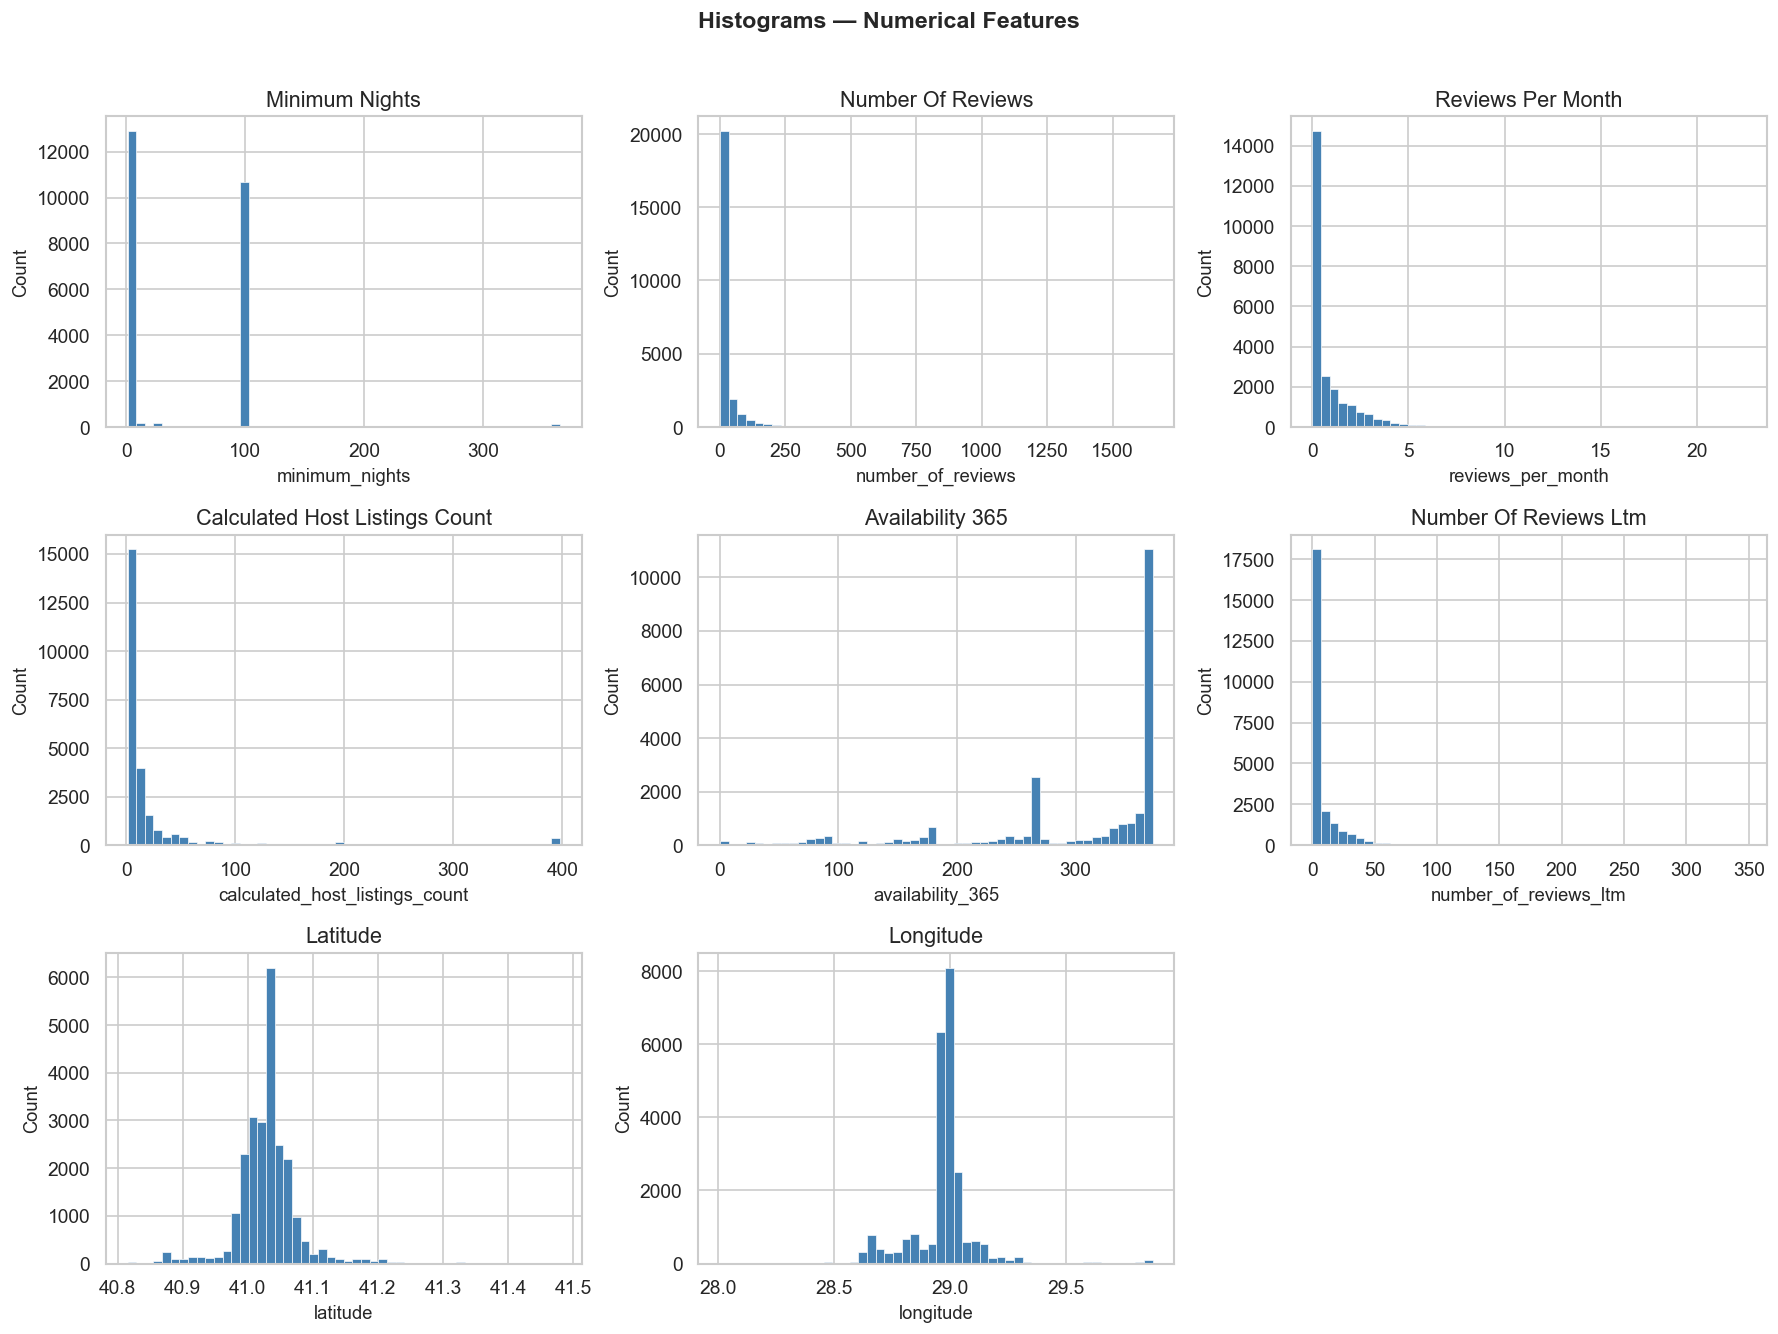

In [474]:
num_features = [
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365',
    'number_of_reviews_ltm', 'latitude', 'longitude'
]

def print_stats(col):
    s = df[col]
    print(f"  mean={s.mean():.3f}  median={s.median():.3f}  "
          f"std={s.std():.3f}  skew={s.skew():.3f}")

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    axes[i].hist(df[feat], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    print(f"\n{feat}:")
    print_stats(feat)

# Hide unused subplot
for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms — Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- `minimum_nights` is right-skewed; many listings require only 1–2 nights, but some hosts set long minimums (likely monthly rentals).
- `number_of_reviews` and `reviews_per_month` are extremely right-skewed — most listings have few reviews, a small fraction are very popular.
- `availability_365` shows a bimodal pattern — a cluster near 0 (always booked or blocked) and another near 365 (always available).
- `latitude` / `longitude` are tightly clustered, consistent with Istanbul's geographic extent.

### 5.3 Categorical Features

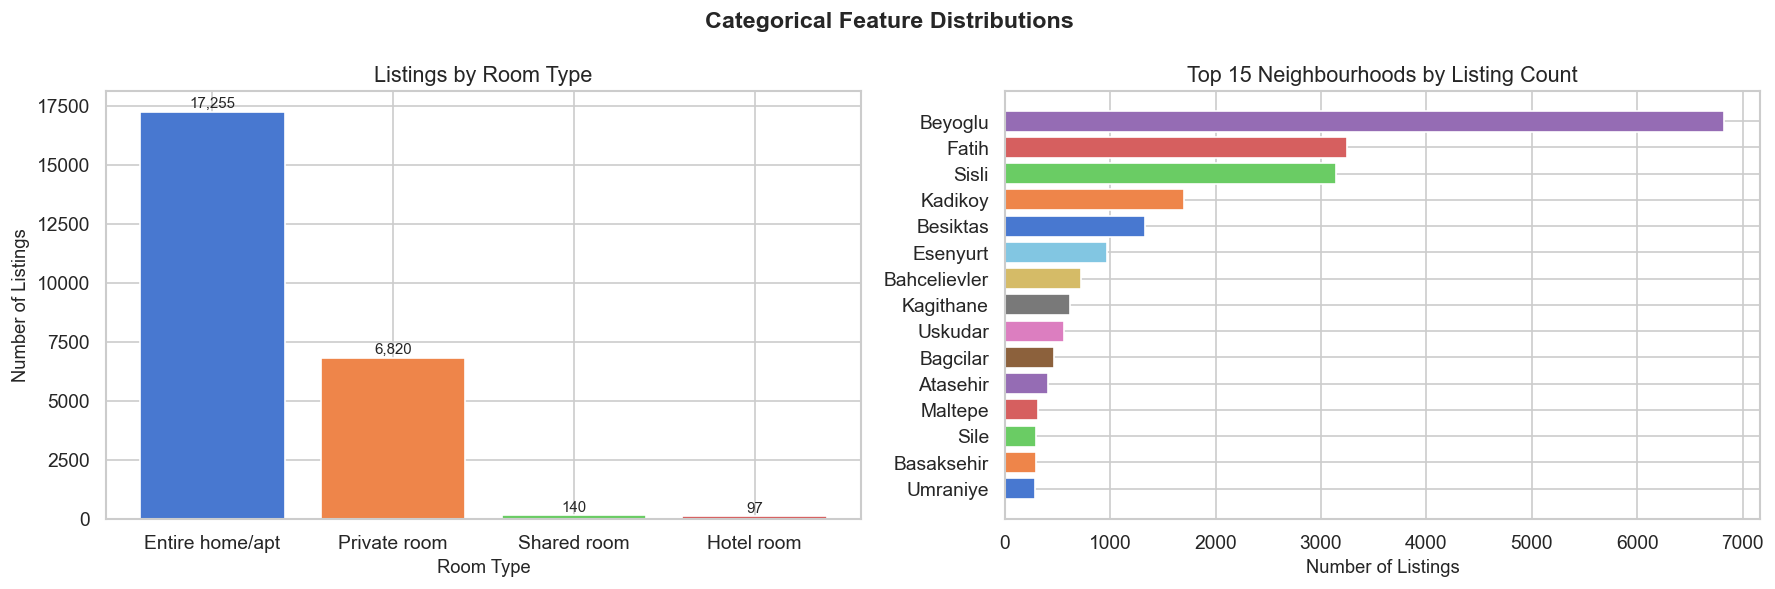


Room type frequencies:
room_type
Entire home/apt    17255
Private room        6820
Shared room          140
Hotel room            97

Top 10 districts:
neighbourhood
Beyoglu         6824
Fatih           3251
Sisli           3146
Kadikoy         1703
Besiktas        1331
Esenyurt         971
Bahcelievler     725
Kagithane        623
Uskudar          559
Bagcilar         464
Atasehir         411
Maltepe          315
Sile             300
Basaksehir       292
Umraniye         286


In [475]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- room_type ----
room_counts = df['room_type'].value_counts()
axes[0].bar(room_counts.index, room_counts.values, color=sns.color_palette('muted', len(room_counts)))
axes[0].set_title('Listings by Room Type')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Number of Listings')
for bar, count in zip(axes[0].patches, room_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f'{count:,}', ha='center', va='bottom', fontsize=9)


# ---- neighbourhood (top 15) ----
ng_counts = df['neighbourhood'].value_counts().head(15)
axes[1].barh(ng_counts.index[::-1], ng_counts.values[::-1],
             color=sns.color_palette('muted', len(ng_counts)))
axes[1].set_title('Top 15 Neighbourhoods by Listing Count')
axes[1].set_xlabel('Number of Listings')


plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nRoom type frequencies:")
print(room_counts.to_string())
print("\nTop 10 districts:")
print(ng_counts.to_string())

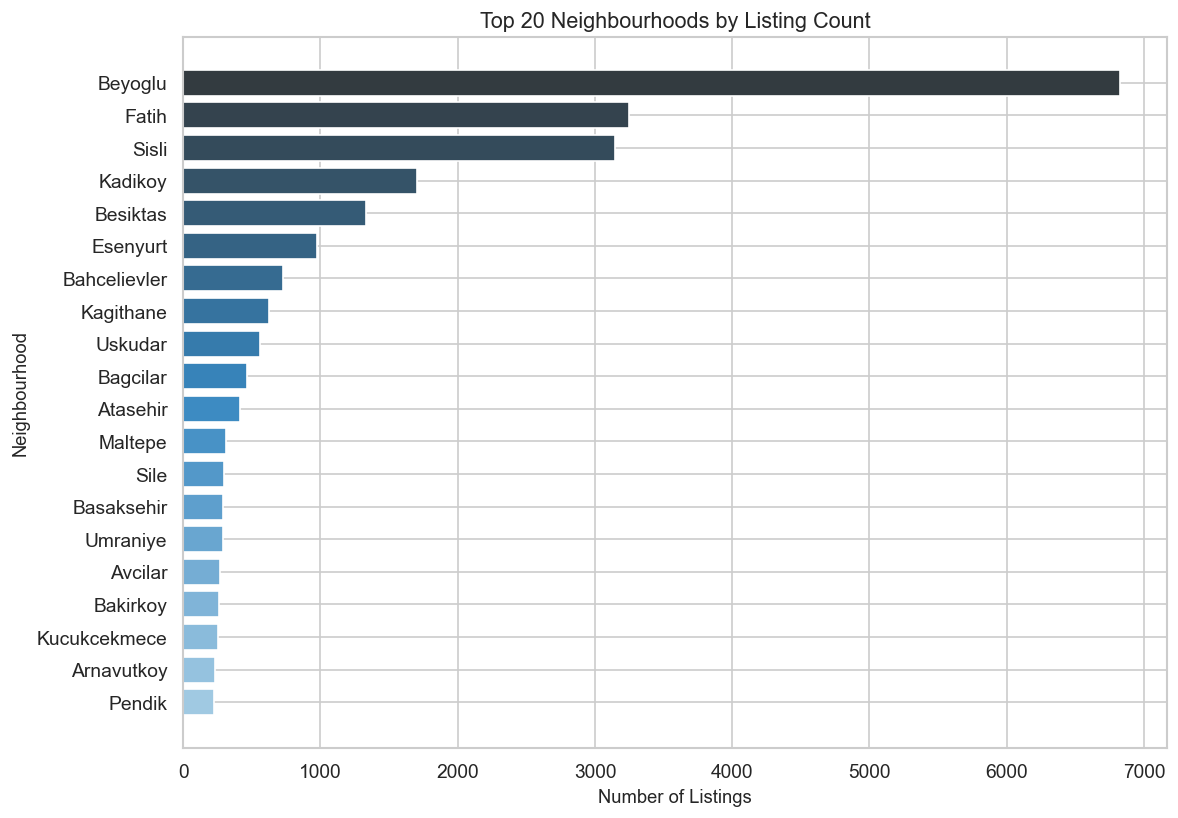

In [476]:
# Top neighbourhoods within districts
top_neighbourhoods = df['neighbourhood'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_neighbourhoods.index[::-1], top_neighbourhoods.values[::-1],
        color=sns.color_palette('Blues_d', len(top_neighbourhoods)))
ax.set_title('Top 20 Neighbourhoods by Listing Count')
ax.set_xlabel('Number of Listings')
ax.set_ylabel('Neighbourhood')
plt.tight_layout()
plt.show()

**Observations:**
- **Entire home/apartment** listings dominate (~65 %), followed by **Private room** (~32 %).
- **Beyoğlu**, **Şişli**, and **Fatih** are the top three districts — all centrally located tourist hubs.
- **Shared rooms** are rare (<2 %) — this class imbalance will need to be handled in P2 if we create room-type submodels.

### 5.4 `has_review` Binary Feature

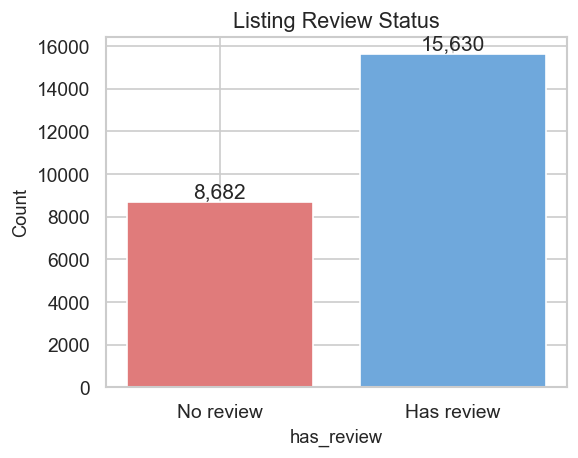

has_review
0     8682
1    15630


In [477]:
fig, ax = plt.subplots(figsize=(5, 4))
hr = df['has_review'].value_counts().reindex([0, 1], fill_value=0)
ax.bar(['No review', 'Has review'], hr.values, color=['#e07b7b', '#6fa8dc'])
ax.set_title('Listing Review Status')
ax.set_xlabel('has_review')
ax.set_ylabel('Count')
for bar, v in zip(ax.patches, hr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()
print(hr.to_string())

---
## 6. Bivariate & Multivariate Analysis

### 6.1 Correlation Heatmap

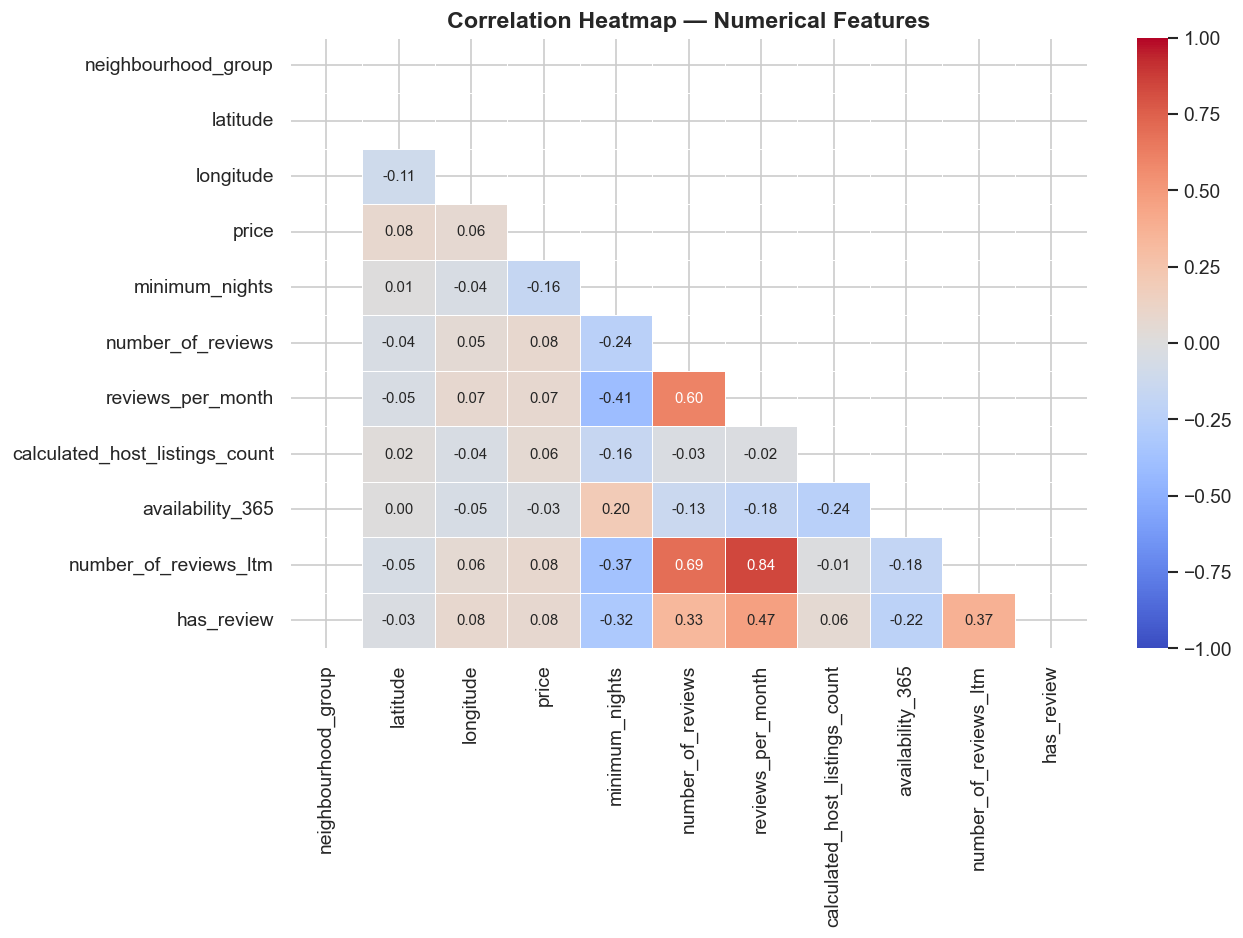


Top correlations with price:
minimum_nights                   -0.164073
number_of_reviews_ltm             0.081541
latitude                          0.080660
number_of_reviews                 0.079572
has_review                        0.076282
reviews_per_month                 0.071877
longitude                         0.064777
calculated_host_listings_count    0.055347
availability_365                 -0.029413
neighbourhood_group                    NaN


In [478]:
numeric_df = df.select_dtypes(include=np.number).drop(columns=['id', 'host_id'], errors='ignore')

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 9}
)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with price
print("\nTop correlations with price:")
price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
print(price_corr.to_string())

**Key observations:**
- `latitude` and `longitude` show a meaningful correlation with price — geographic location strongly influences pricing.
- `calculated_host_listings_count` has a moderate positive correlation with price — professional hosts (with many listings) tend to operate higher-end properties.
- `number_of_reviews` and `reviews_per_month` are strongly correlated with each other — multicollinearity to address in P2.
- `availability_365` shows a weak negative correlation with price — cheaper listings tend to be available more of the year.

### 6.2 Price by Room Type

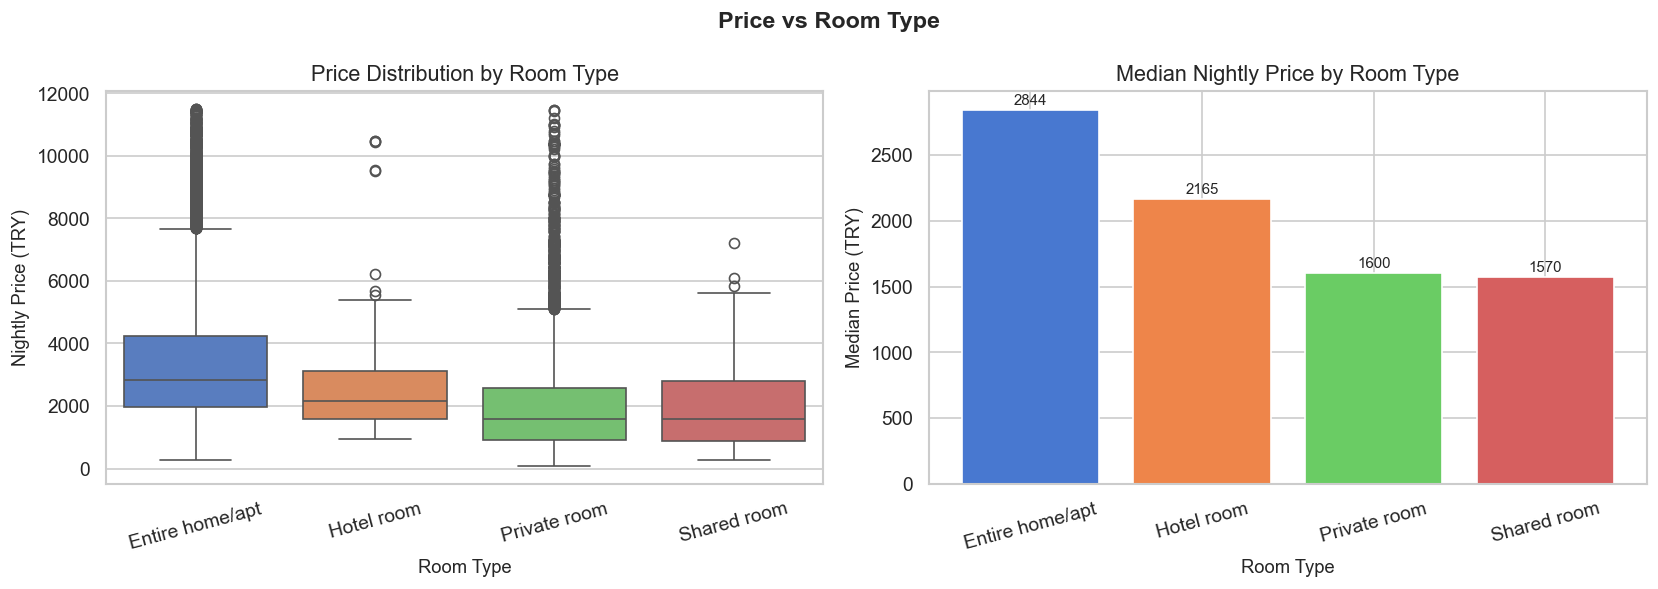

In [479]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
room_order = df.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='room_type', y='price', order=room_order,
            palette='muted', ax=axes[0])
axes[0].set_title('Price Distribution by Room Type')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Nightly Price (TRY)')
axes[0].tick_params(axis='x', rotation=15)

# Median price bar chart
medians = df.groupby('room_type')['price'].median().sort_values(ascending=False)
axes[1].bar(medians.index, medians.values, color=sns.color_palette('muted', len(medians)))
axes[1].set_title('Median Nightly Price by Room Type')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Median Price (TRY)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(axes[1].patches, medians.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Price vs Room Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Hotel rooms and entire homes command significantly higher median prices than private or shared rooms. `room_type` will be a strong categorical predictor in P2.

### 6.3 Price by District

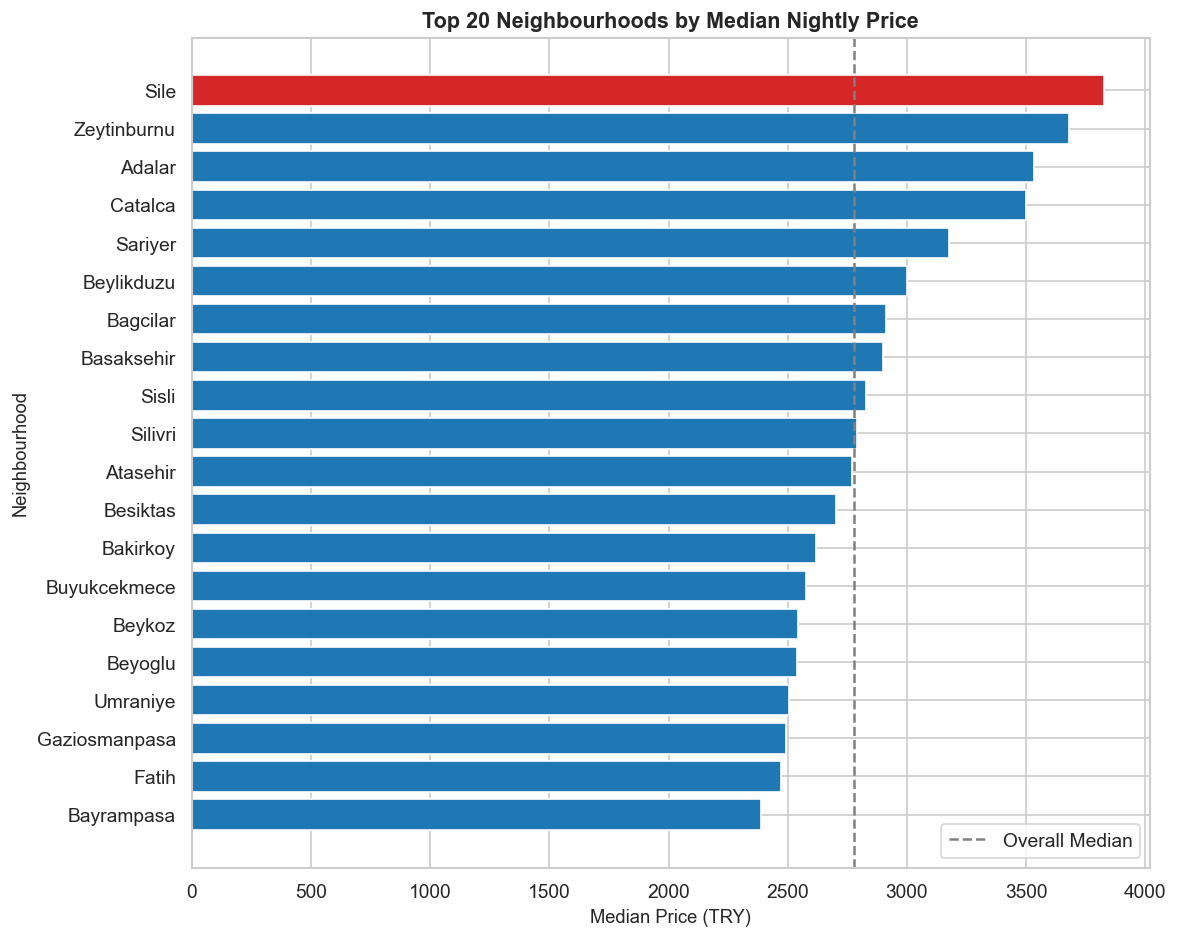

In [480]:
# Median price per neighbourhood (top 20), since neighbourhood_group is not available for Istanbul
district_price = (df.groupby('neighbourhood')['price']
                    .median()
                    .sort_values(ascending=True)
                    .tail(20))

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if v == district_price.max() else '#1f77b4' for v in district_price.values]
ax.barh(district_price.index, district_price.values, color=colors)
ax.set_title('Top 20 Neighbourhoods by Median Nightly Price', fontweight='bold')
ax.set_xlabel('Median Price (TRY)')
ax.set_ylabel('Neighbourhood')
ax.axvline(district_price.median(), color='gray', linestyle='--', label='Overall Median')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** There is substantial price variation across Istanbul's districts. Upscale waterfront and historic districts command premiums, while peripheral districts are significantly cheaper.

### 6.4 Scatter Plots — Key Numeric Features vs Price

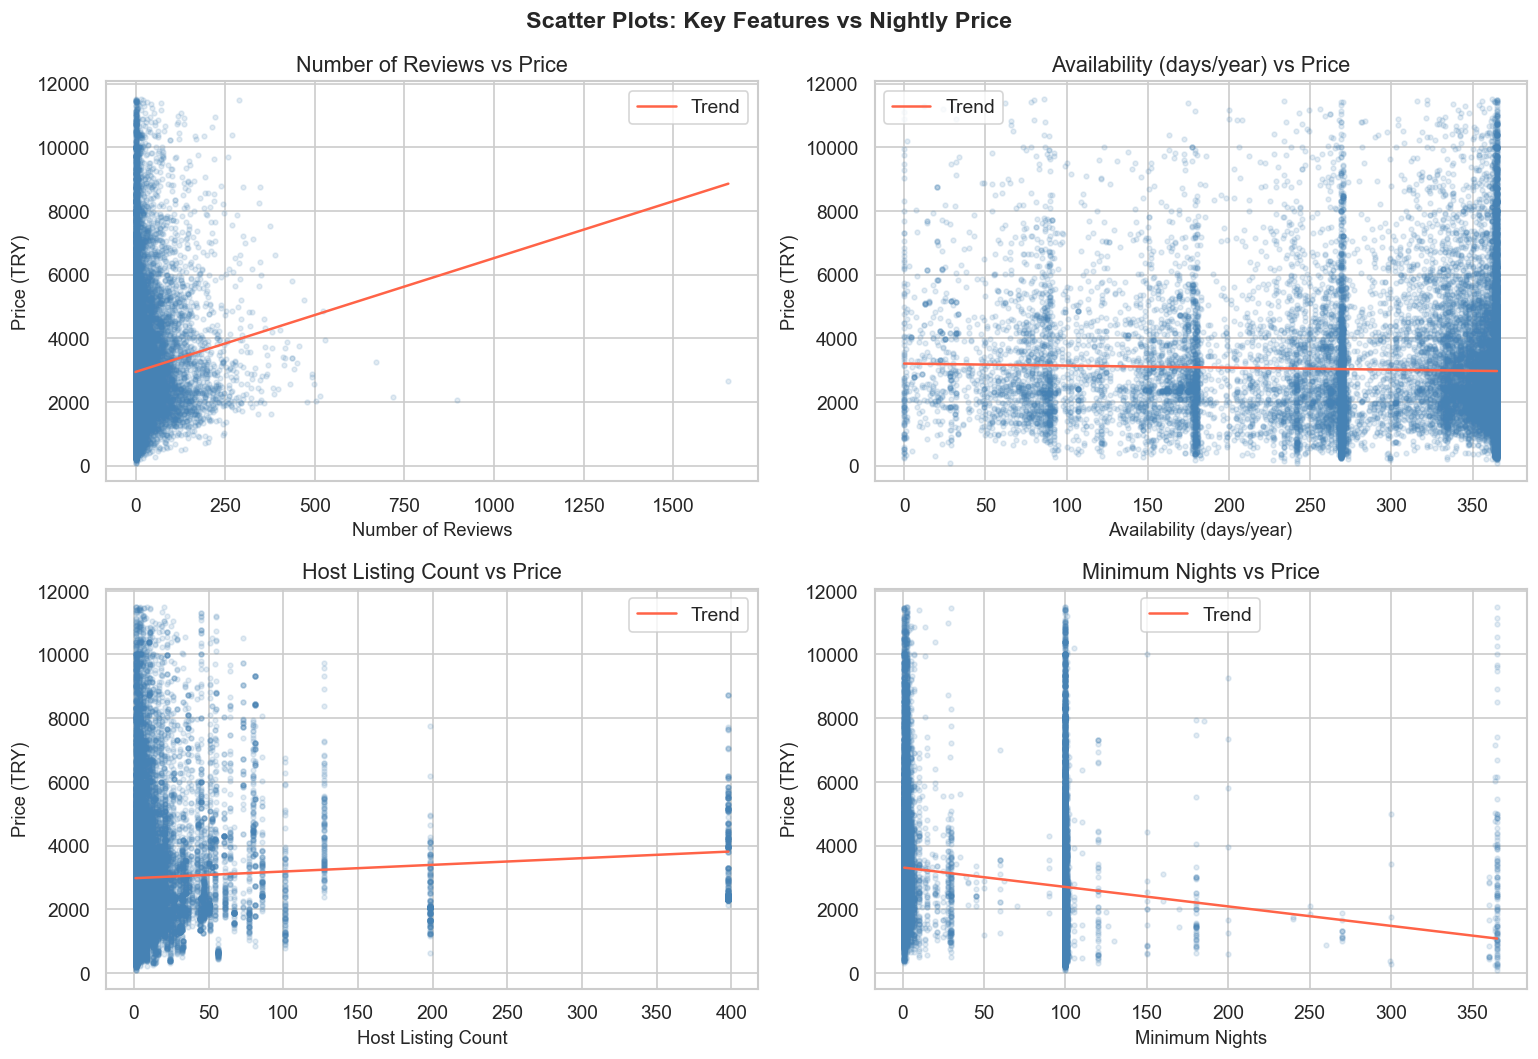

In [481]:
scatter_features = [
    ('number_of_reviews', 'Number of Reviews'),
    ('availability_365', 'Availability (days/year)'),
    ('calculated_host_listings_count', 'Host Listing Count'),
    ('minimum_nights', 'Minimum Nights'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (feat, label) in enumerate(scatter_features):
    clean = df[[feat, 'price']].dropna()
    if len(clean) == 0:
        axes[i].set_visible(False)
        continue
    axes[i].scatter(clean[feat], clean['price'], alpha=0.15, s=8, color='steelblue')
    # Trend line
    z = np.polyfit(clean[feat], clean['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(clean[feat].min(), clean[feat].max(), 200)
    axes[i].plot(x_line, p(x_line), color='tomato', linewidth=1.5, label='Trend')
    axes[i].set_title(f'{label} vs Price')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Price (TRY)')
    axes[i].legend()

plt.suptitle('Scatter Plots: Key Features vs Nightly Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.5 Geographic Price Map (Latitude vs Longitude)

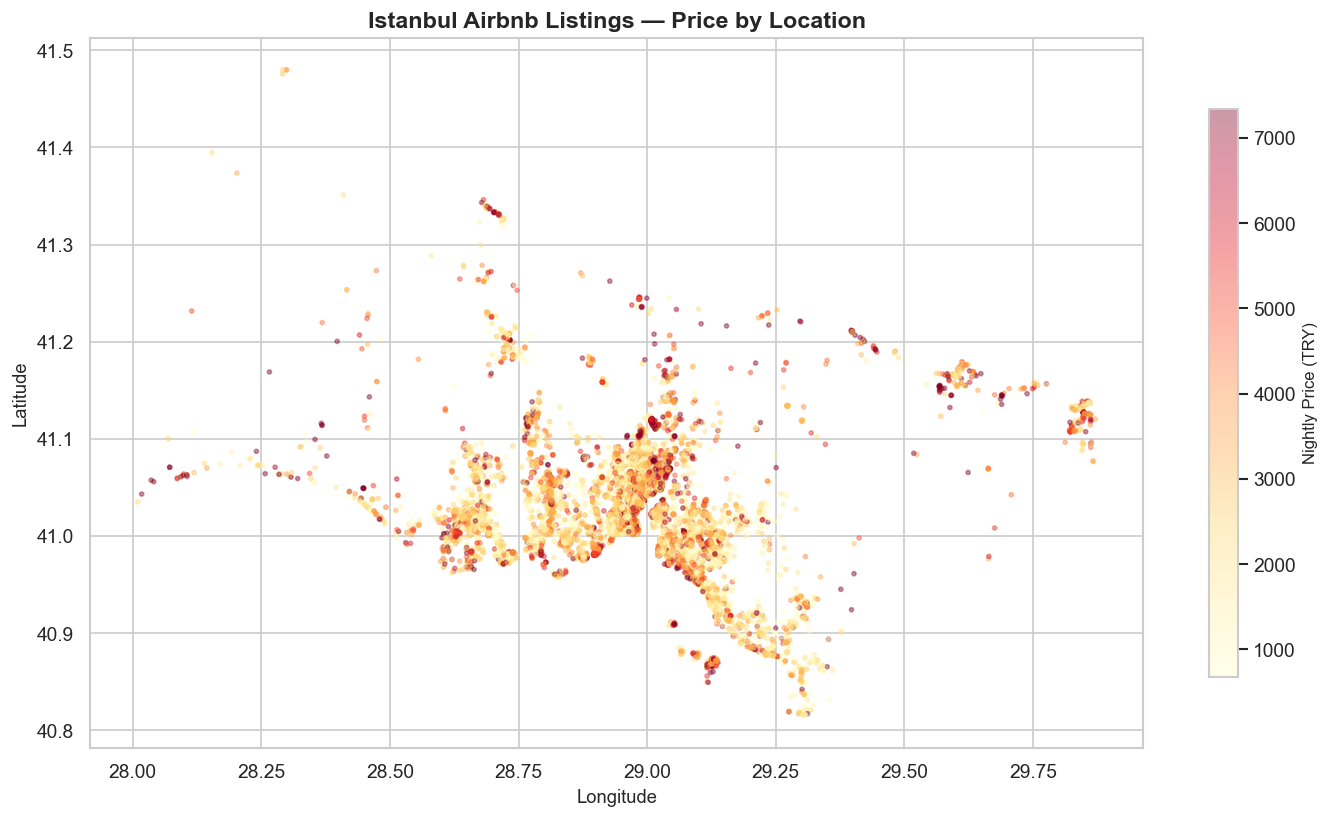

In [482]:
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(
    df['longitude'], df['latitude'],
    c=df['price'], cmap='YlOrRd',
    alpha=0.4, s=6, vmin=df['price'].quantile(0.05), vmax=df['price'].quantile(0.95)
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Nightly Price (TRY)', fontsize=10)
ax.set_title('Istanbul Airbnb Listings — Price by Location', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

**Insight:** The geographic scatter plot reveals clear spatial price clusters. Higher-priced listings (yellow/red) concentrate in the European side's central corridor (Beyoğlu, Beşiktaş, Şişli) and along the Bosphorus, while lower-priced listings (darker) appear in peripheral Asian and European side neighbourhoods.

### 6.6 Reviews vs Price — by Room Type

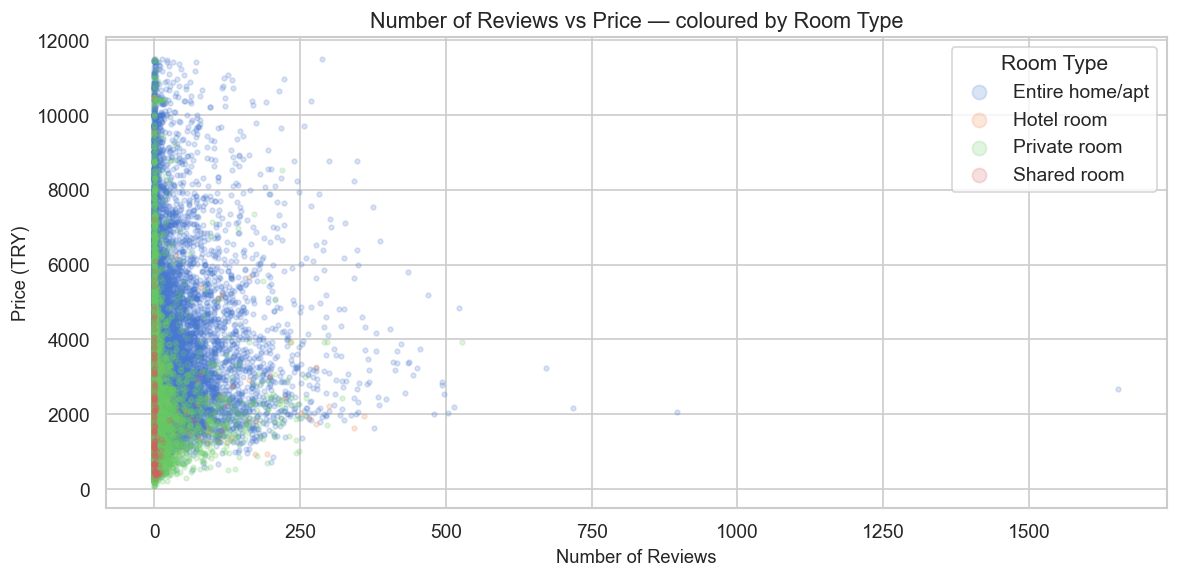

In [483]:
fig, ax = plt.subplots(figsize=(10, 5))
for rtype, grp in df.groupby('room_type', observed=True):
    ax.scatter(grp['number_of_reviews'], grp['price'],
               alpha=0.2, s=8, label=rtype)
ax.set_title('Number of Reviews vs Price — coloured by Room Type')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Price (TRY)')
ax.legend(title='Room Type', markerscale=3)
plt.tight_layout()
plt.show()

### 6.7 Pairplot — Top Features

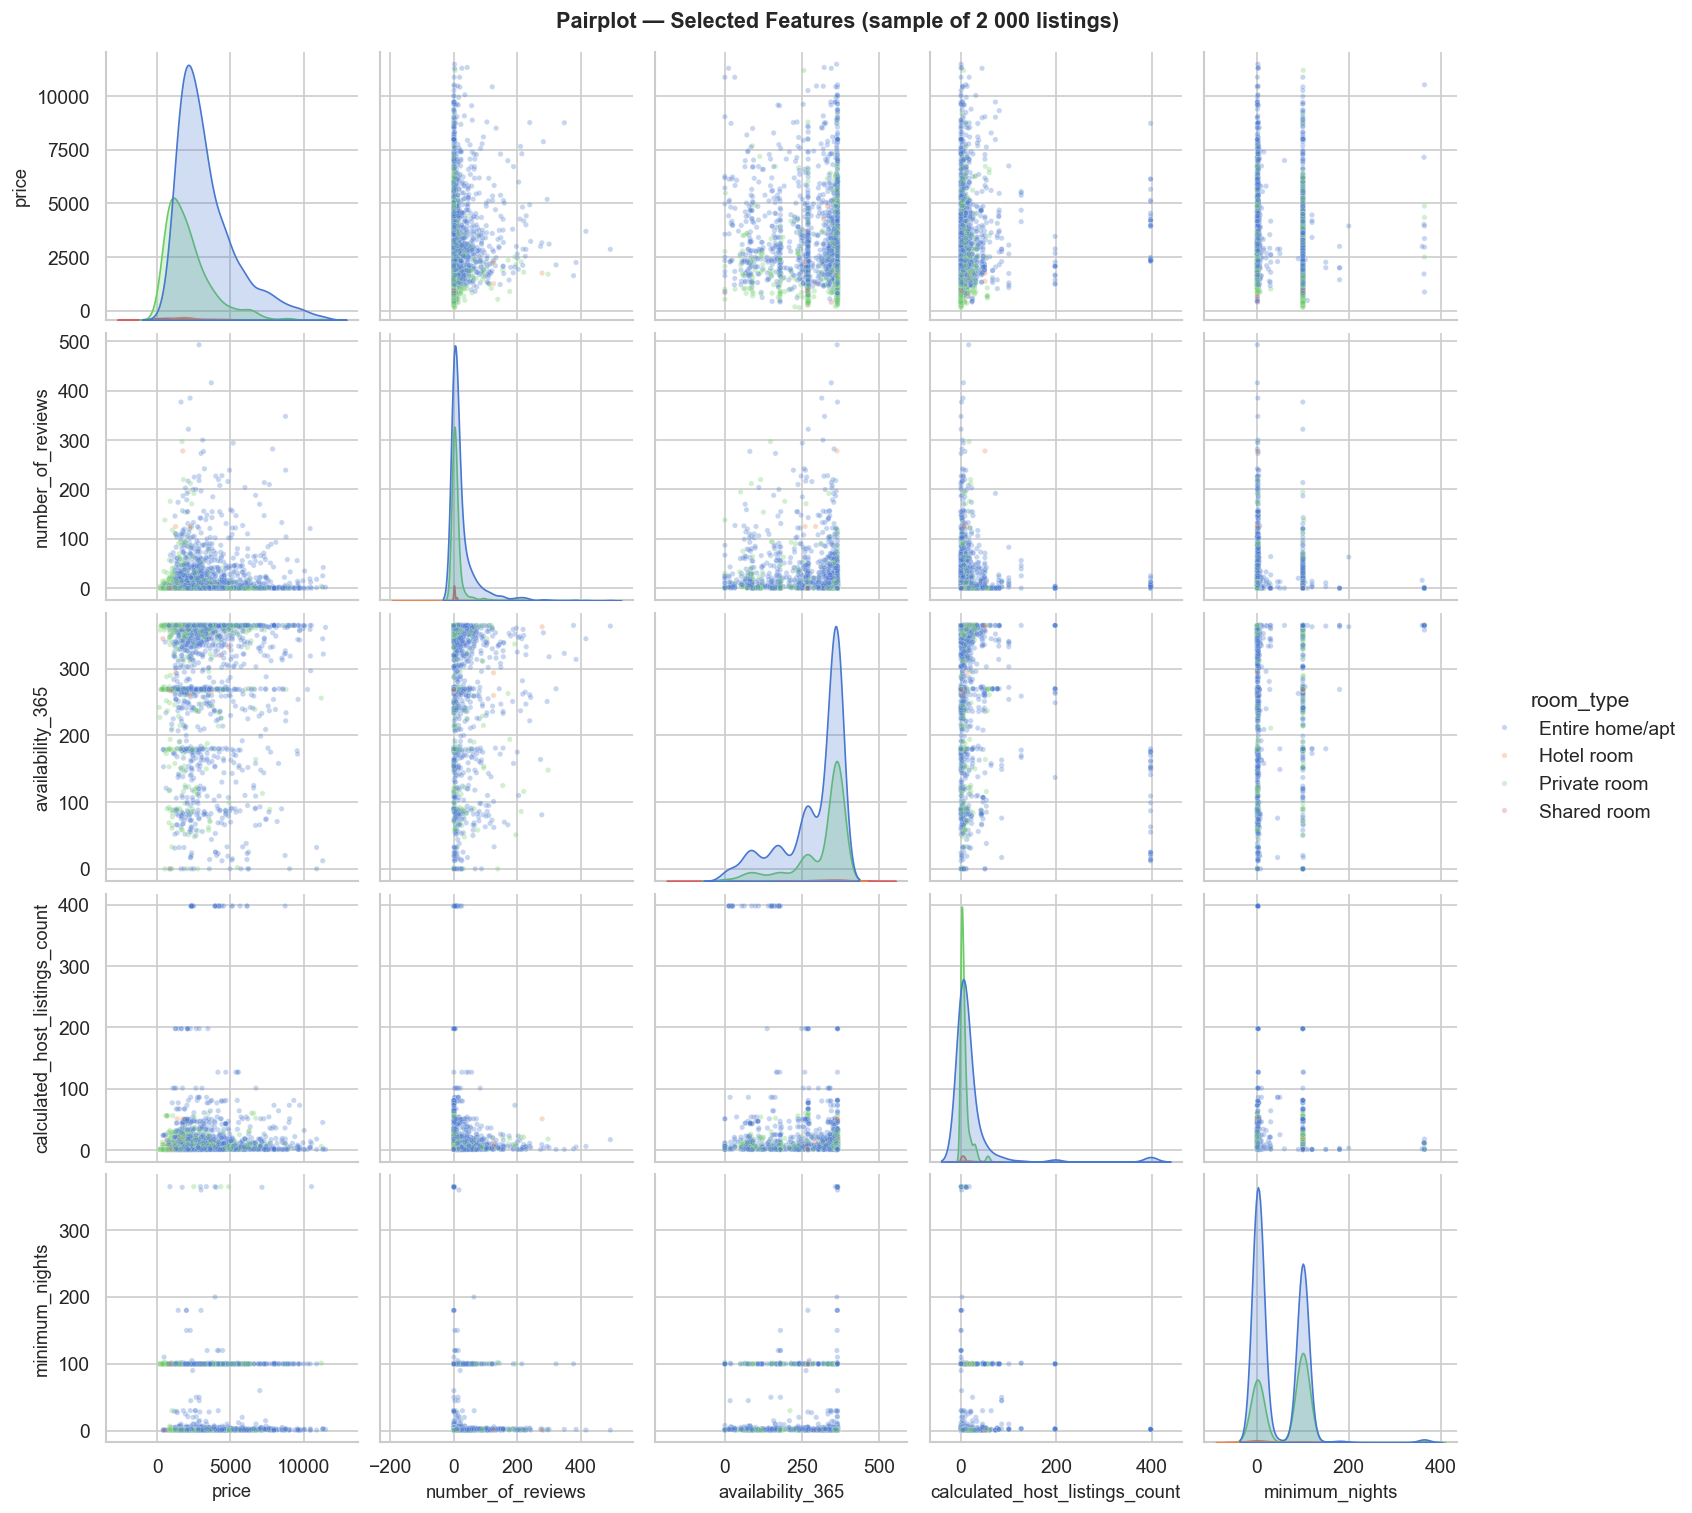

In [484]:
pair_cols = ['price', 'number_of_reviews', 'availability_365',
             'calculated_host_listings_count', 'minimum_nights']

pair_df = df[pair_cols + ['room_type']].sample(min(2000, len(df)), random_state=RANDOM_SEED)

g = sns.pairplot(pair_df, hue='room_type', diag_kind='kde',
                 plot_kws={'alpha': 0.3, 's': 10},
                 vars=pair_cols)
g.fig.suptitle('Pairplot — Selected Features (sample of 2 000 listings)',
                y=1.01, fontsize=13, fontweight='bold')
plt.show()

---
## 7. Key Findings & Next Steps

### 7.1 Summary of Key Findings

1. **Room type is the single strongest predictor.** Entire homes/apartments cost 2–3× more per night than private rooms on average. This categorical variable will be one-hot encoded in P2 and should enter every baseline model.

2. **Location matters as much as property type.** Both `latitude` / `longitude` and `neighbourhood_group` show strong relationships with price. A Bosphorus-facing flat in Beşiktaş commands a clear premium over a similarly sized flat in a peripheral district. We will engineer a `district_median_price` feature in P2.

3. **Price is strongly right-skewed — log transformation is required.** Raw price violates normality assumptions. Modelling on log(price) and back-transforming predictions will improve regression accuracy and reduce the influence of extreme values.

4. **Reviews proxy occupancy but suffer from multicollinearity.** `number_of_reviews`, `reviews_per_month`, and `number_of_reviews_ltm` are highly correlated. In P2 we will keep only the most informative of the three (likely `reviews_per_month`) and drop the others to avoid multicollinearity.

5. **Availability has a counter-intuitive pattern.** Listings that are available nearly year-round are often *cheaper* — possibly indicating low demand, not owner choice. This is a useful signal for the model.

### 7.2 Most Predictive Features and Why

| Feature | Expected Importance | Reason |
|---|---|---|
| `room_type` | ★★★★★ | Large price gap between entire homes and private rooms |
| `neighbourhood_group` | ★★★★★ | Central districts command clear price premiums |
| `latitude` / `longitude` | ★★★★☆ | Fine-grained spatial variation within districts |
| `calculated_host_listings_count` | ★★★☆☆ | Professional hosts correlate with higher-end properties |
| `minimum_nights` | ★★★☆☆ | Long minimums signal monthly-rental positioning (lower nightly price) |
| `availability_365` | ★★☆☆☆ | Proxy for demand; low availability = popular = higher price |

### 7.3 Remaining Data Quality Issues

- **No amenity data:** The simplified CSV does not include amenity lists (pool, parking, WiFi, etc.) — these would likely be strong predictors. For P2 we may merge with the full listings CSV.
- **Currency inflation:** The dataset is a single 2024 snapshot. If used for forecasting, inflation trends should be accounted for.
- **`last_review` date:** Not yet used as a feature. In P2, we will compute `days_since_last_review` to capture listing freshness.

### 7.4 Roadmap to P2 and P3

**P2 (Model Training):**
- Apply log transform to price before fitting.
- Feature engineering: `district_median_price`, `days_since_last_review`, `is_professional_host`.
- Baseline models: Linear Regression, Ridge, Random Forest.
- Evaluation: RMSE, MAE, R² on log-price; report actual-price errors after back-transform.

**P3 (Optimisation & Deployment):**
- Hyperparameter tuning (Grid/RandomSearchCV).
- Model explainability (SHAP values) — which features matter most?
- (Optional) Build a simple price-suggestion API or Streamlit app.

In [485]:
# Save the cleaned dataset for use in P2
df.to_csv('istanbul_airbnb_cleaned.csv', index=False)
print(f"Cleaned dataset saved: istanbul_airbnb_cleaned.csv")
print(f"Final shape: {df.shape}")
print(f"Price range: {df['price'].min():.0f} – {df['price'].max():.0f} TRY")
print(f"Unique neighbourhoods: {df['neighbourhood'].nunique()}")
print(f"Unique room types: {df['room_type'].nunique()}")
print(f"Unique neighbourhoods: {df['neighbourhood'].nunique()}")

Cleaned dataset saved: istanbul_airbnb_cleaned.csv
Final shape: (24312, 16)
Price range: 80 – 11500 TRY
Unique neighbourhoods: 39
Unique room types: 4
Unique neighbourhoods: 39
